# Lab 2: Methods in Linear Regression

## Problems:

### Problem 1: Bootstrapping a Confidence Interval

If we don't have a formula for the confidence interval of a statistic, we can often estimate it by sampling from out data set many times, computing the statistic of interest, and then plotting the distribution. This is known as __bootstrapping__ the confidence interval, since you're using the data to make estimates about your fits, effectively pulling yourself up by your bootstraps. In this problem, we will see how to boot strap the confidence interval for the $\beta$ parameters in the linear fit. 

__Continue with the Lab2 Master file.__ Lets return to the one variable examples of fitting the sales price to the first floor square footage __1stFlrSF__. Using a for loop, compute $\beta_0$ and $\beta_1$ 1000 times for samples of size $N = 1436$ __with replacement__ and store their results in vectors, as in the code below. 


In [4]:
# Setup: load and clean the Ames data (same steps as lab_2_master cells 2-10)
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import io
import requests

url = "https://raw.githubusercontent.com/tipthederiver/Math-7243-2020/master/Datasets/Ames/train.csv"
s = requests.get(url).content
ames = pd.read_csv(io.StringIO(s.decode('utf-8')))

z = ames['GrLivArea']+ames['BsmtUnfSF']<4000
data = ames[z]
data = data.select_dtypes(include=['int64','float64'])
data = data.drop(columns='MSSubClass')

print("Rows in data:", len(data))

Rows in data: 1436


In [5]:
N = 1000

beta0 = np.zeros(N)
beta1 = np.zeros(N)

for i in range(N):
    # 1. resample rows of the data, with replacement
    sample = data.sample(n=len(data), replace=True)

    # 2. Build X (with a column of 1's) and Y
    X = np.matrix(sample["1stFlrSF"]).reshape(-1, 1)
    Y = np.matrix(sample["SalePrice"]).reshape(-1, 1)
    Xa = np.append(np.ones(X.shape), X, 1)

    # 3. Fit
    betas = (Xa.T*Xa).I*Xa.T*Y

    # 4. Store
    beta0[i] = betas[0, 0]
    beta1[i] = betas[1, 0]
    

__Turn in__

1. Plot a histogram of $\beta_0$ and $\beta_1$. 
2. Using `beta0.sort()`, sort the values and find the interval containing the middle 950 values. This is the bootstrap 95% confidence interval. 
3. Using the formulas from (Section 4.Statistics for ML. Sec4StatisticsML.pdf page 17.), compute the confidence interval. Remember that here you use all of the training data. Compare your results. 


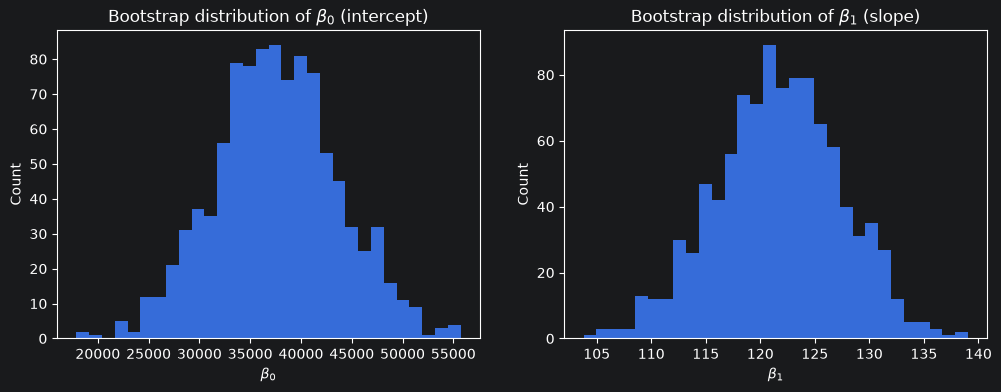

In [12]:
"""
Part a: Plot a historgram of b_0, b_1
"""

fig, axes = plt.subplots(1, 2)
fig.set_size_inches(12, 4)

axes[0].hist(beta0, bins=30)
axes[0].set_title("Bootstrap distribution of $\\beta_0$ (intercept)")
axes[0].set_xlabel("$\\beta_0$")
axes[0].set_ylabel("Count")

axes[1].hist(beta1, bins=30)
axes[1].set_title("Bootstrap distribution of $\\beta_1$ (slope)")
axes[1].set_xlabel("$\\beta_1$")
axes[1].set_ylabel("Count")

plt.show()

95% bootstrap CI for beta0: 26000.329726477667 to 49953.894335001045
95% bootstrap CI for beta1: 110.09400177274841 to 132.3172230943209


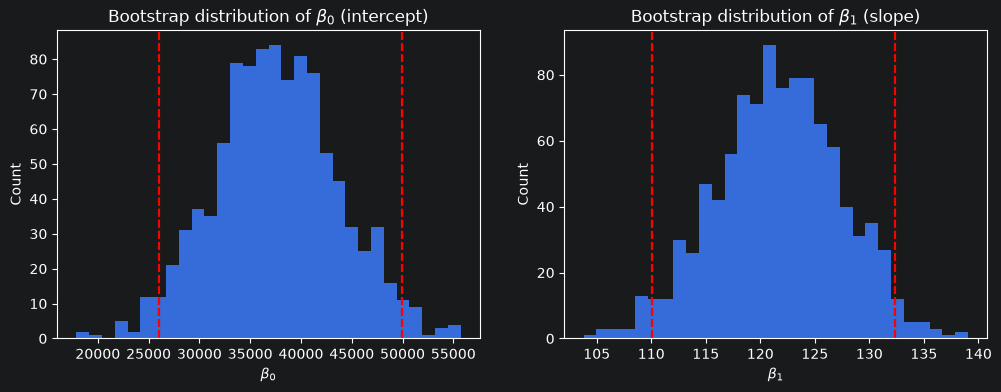

In [15]:
"""
Part b: Using beta0.sort(), sort the values and find the interval containing the middle
950 values. This is the bootstrap 95% confidence interval.
"""

beta0.sort()
beta1.sort()

print("95% bootstrap CI for beta0:", beta0[25], "to", beta0[974])
print("95% bootstrap CI for beta1:", beta1[25], "to", beta1[974])

axes[0].axvline(beta0[25], color="r", linestyle="--")
axes[0].axvline(beta0[974], color="r", linestyle="--")
axes[1].axvline(beta1[25], color="r", linestyle="--")
axes[1].axvline(beta1[974], color="r", linestyle="--")

display(fig)

In [18]:
"""
Part c: Using the formulas from (Section 4.Statistics for ML. Sec4StatisticsML.pdf
page 17.), compute the confidence interval. Remember that here you use all of the
training data. Compare your results.

Recall:
Cov(theta) = variance * (X.T*X)^-1
"""

X = np.matrix(data["1stFlrSF"]).reshape(-1, 1)
Y = np.matrix(data["SalePrice"]).reshape(-1, 1)
Xa = np.append(np.ones(X.shape), X, 1)
n = len(Y)

betas = (Xa.T*Xa).I*Xa.T*Y
RSS = ((Y - Xa*betas).T*(Y - Xa*betas))[0, 0]
sigma2 = RSS/(n - 2)

var_betas = sigma2*(Xa.T*Xa).I
se = np.sqrt(np.diag(var_betas))

print("Formula 95% CI for beta0:", betas[0, 0] - 1.96*se[0], "to", betas[0, 0] + 1.96*se[0])
print("Formula 95% CI for beta1:", betas[1, 0] - 1.96*se[1], "to", betas[1, 0] + 1.96*se[1])

print("Bootstrap std of beta0:", np.std(beta0), " formula SE:", se[0])
print("Bootstrap std of beta1:", np.std(beta1), " formula SE:", se[1])




Formula 95% CI for beta0: 27673.928303483866 to 47457.57831937423
Formula 95% CI for beta1: 113.5237968351997 to 129.98874034775048
Bootstrap std of beta0: 6087.6499937444805  formula SE: 5046.849493849582
Bootstrap std of beta1: 5.741277740136152  formula SE: 4.200240691977241


###### Problem 2: Linear Methods on High Dimensional Data

Perform ridge regression and lasso regression on the MRI Slices dataset on blackboard. You should follow the __Loading the Viewing MRI Slices__ notebook, eventually loading all slices into Python as a data matrix, with all picture dimensions flattened. The text and code for that process has been reproduced below.

We want to fit the MRI Slices data to the __Normalized Whole-brain Volume (nWBV)__ in the labels data.


__Turn in__: 

1. Given the train-test split with seed random_state=$255$, what is the best $\alpha$ value for pure Ridge Regression? Justify your answer. 
2. Given the train-test split with seed random_state=$255$, what is the best $\lambda$ value for pure Lasso Regression? Justify your answer. 
3. (Bonus) What is the best $(\alpha,\lambda)$ value for elastic net regression?

You may set the downsample rate to higher you are unable to compute the linear model.

random_state= 255 will fix the random set. See Wiki for a quick explanation.  https://en.wikipedia.org/wiki/Random_seed
Or https://machinelearningmastery.com/train-test-split-for-evaluating-machine-learning-algorithms/ for some more details. 

### Load MRI All Files

To load all of the files into an array we need to be able to search through the directory. Luckily, this is easy to do using the labels file, since each file name is stored there. We just need to loop through the __Filename__ column in the `labels` dataset and load them into an array one by one. There are 702 files in total. 

With the array there are two ways we can load them in: First, we can load them into a $609\times 176 \times 176$ array, which is the best option if we care about the 2D structure. However for algorithms like linear regression that can not see the 2D structure, we may want to flatten the images to a $609\times 30976$ array (note that $30976 = 176 \times 176$). Its easy enough two switch back and forth between the two array structures later. We will start with the flattened array. 

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib

file_dir = 'data/'

labels = pd.read_csv(file_dir + 'labels.csv')
display(labels)

,Unnamed: 0,Filename,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,Slice
0,0,OAS1_0001_MR1_55.png,OAS1_0001_MR1,F,R,74,2,3.0,29,0.0,1344,0.743,1.306,NaN,55
1,1,OAS1_0001_MR1_120.png,OAS1_0001_MR1,F,R,74,2,3.0,29,0.0,1344,0.743,1.306,NaN,120
2,2,OAS1_0001_MR1_180.png,OAS1_0001_MR1,F,R,74,2,3.0,29,0.0,1344,0.743,1.306,NaN,180
3,3,OAS1_0002_MR1_55.png,OAS1_0002_MR1,F,R,55,4,1.0,29,0.0,1147,0.810,1.531,NaN,55
4,4,OAS1_0002_MR1_120.png,OAS1_0002_MR1,F,R,55,4,1.0,29,0.0,1147,0.810,1.531,NaN,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,604,OAS1_0449_MR1_120.png,OAS1_0449_MR1,F,R,71,3,4.0,29,0.0,1264,0.818,1.388,NaN,120
605,605,OAS1_0449_MR1_180.png,OAS1_0449_MR1,F,R,71,3,4.0,29,0.0,1264,0.818,1.388,NaN,180
606,606,OAS1_0456_MR1_55.png,OAS1_0456_MR1,M,R,61,5,2.0,30,0.0,1637,0.780,1.072,NaN,55
607,607,OAS1_0456_MR1_120.png,OAS1_0456_MR1,M,R,61,5,2.0,30,0.0,1637,0.780,1.072,NaN,120


In [3]:
DS = 8             # Downsample rate, must be a multiple of 30976

if 30976/DS % 1 > 0:
    print("Downsample rate is not a multiple of 30976")
    DS = 1
    im_size = 30976
else:
    im_size = int(30976/DS)


data = np.zeros([609, im_size])

for i, file_name in enumerate(labels.Filename):
    img = np.mean(matplotlib.image.imread(file_dir + file_name),axis=2).reshape(-1)
    data[i,:] = img[::DS]            # Downsample the image

In [4]:
data.shape

(609, 3872)

In [9]:
"""
Part a: Given the train-test split with seed random_state=255, what is
the best alpha value for pure Ridge Regression? Justify your answer.
"""
from sklearn.model_selection import train_test_split

X = data
y = labels["nWBV"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=255
)

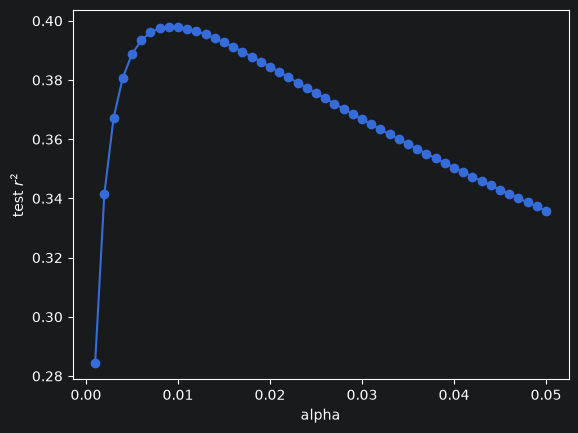

Best alpha: 0.009000000000000001 with test r^2 = 0.39801484655264985


In [13]:
import statsmodels.api as sm
from sklearn.metrics import r2_score

alphas = np.linspace(0.001, 0.05, 50)
r_sqds = []

for alp in alphas:
    ols = sm.OLS(y_train, sm.add_constant(x_train, has_constant="add"))
    ols_result = ols.fit_regularized(L1_wt=0, alpha=alp)
    pred = ols_result.predict(sm.add_constant(x_test, has_constant="add"))
    r_sqds.append(r2_score(y_test, pred))

plt.plot(alphas, r_sqds, "o-")
plt.xlabel("alpha"); plt.ylabel("test $r^2$")
plt.show()

best = np.argmax(r_sqds)
print("Best alpha:", alphas[best], "with test r^2 =", r_sqds[best])

In [17]:
"""
Answer: α ≈ 0.009, which gives a test r_2 score of about .398.
Method: I split the 609 MRI images 80/20 into a training set of 487 and a test set of 122,
using random_state=255. Each image was downsampled to 3872 pixel features.
I fit pure ridge regression with statsmodels and scored each model by its r_2 on the test set.
I searched in two stages. First, a coarse sweep over 10^-6 to 10^3 showed the test r_2 peaking
near 10^-2. Then a finer sweep of 50 values between .001 and .05 located the maximum value at .009
"""

'\nAnswer: α ≈ 0.009, which gives a test r_2 score of about .398.\nMethod: I split the 609 MRI images 80/20 into a training set of 487 and a test set of 122,\nusing random_state=255. Each image was downsampled to 3872 pixel features.\nI fit pure ridge regression with statsmodels and scored each model by its r_2 on the test set.\nI searched in two stages. First, a coarse sweep over 10^-6 to 10^3 showed the test r_2 peaking\nnear 10^-2. Then a finer sweep of 50 values between .001 and .05 located the maximum value at .009\n'

lambda=1e-06  test r^2=0.004  pixels kept=496
lambda=1e-05  test r^2=0.200  pixels kept=377
lambda=1e-04  test r^2=0.366  pixels kept=77
lambda=1e-03  test r^2=-0.048  pixels kept=0
lambda=1e-02  test r^2=-0.048  pixels kept=0
lambda=1e-01  test r^2=-0.048  pixels kept=0
lambda=1e+00  test r^2=-0.048  pixels kept=0
lambda=1e+01  test r^2=-0.048  pixels kept=0
lambda=1e+02  test r^2=-0.048  pixels kept=0
lambda=1e+03  test r^2=-0.048  pixels kept=0


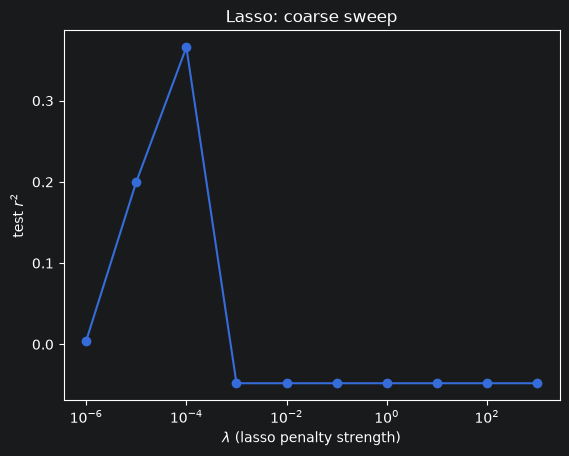

Best lambda: 0.0001 with test r^2 = 0.36580509174092


In [18]:
"""
Part b: Given the train-test split with seed random_state=255, what is the best lambda value
for pure Lasso Regression? Justify your answer.

Notation: here lambda is the lasso penalty strength, as in the textbook's lasso loss
    (1/2n) * RSS + lambda * sum |beta_i|
In sklearn's Lasso (and statsmodels' fit_regularized) this parameter is called `alpha`,
so we pass each lambda in as alpha=lam. (In the lab's elastic-net notation, pure lasso
fixes L1_wt = 1 and the penalty strength is the only thing left to tune.)
"""
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Lasso

# Small lambdas don't fully converge; those models overfit and aren't candidates anyway
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Coarse sweep: one lambda per power of 10 to find the right order of magnitude
lambdas = np.logspace(-6, 3, 10)
r_sqds = []
n_nonzero = []

for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=10_000)
    lasso.fit(x_train, y_train)
    r_sqds.append(r2_score(y_test, lasso.predict(x_test)))
    n_nonzero.append(np.sum(lasso.coef_ != 0))
    print(f"lambda={lam:.0e}  test r^2={r_sqds[-1]:.3f}  pixels kept={n_nonzero[-1]}")

plt.semilogx(lambdas, r_sqds, "o-")
plt.xlabel("$\\lambda$ (lasso penalty strength)"); plt.ylabel("test $r^2$")
plt.title("Lasso: coarse sweep")
plt.show()

best = np.argmax(r_sqds)
print("Best lambda:", lambdas[best], "with test r^2 =", r_sqds[best])

lambda=1.00e-05  test r^2=0.200  pixels kept=377
lambda=4.41e-05  test r^2=0.384  pixels kept=194
lambda=7.83e-05  test r^2=0.377  pixels kept=96
lambda=1.12e-04  test r^2=0.359  pixels kept=67
lambda=1.47e-04  test r^2=0.336  pixels kept=50
lambda=1.81e-04  test r^2=0.316  pixels kept=41
lambda=2.15e-04  test r^2=0.296  pixels kept=42
lambda=2.49e-04  test r^2=0.269  pixels kept=36
lambda=2.83e-04  test r^2=0.236  pixels kept=37
lambda=3.17e-04  test r^2=0.206  pixels kept=30
lambda=3.51e-04  test r^2=0.173  pixels kept=28
lambda=3.86e-04  test r^2=0.142  pixels kept=22
lambda=4.20e-04  test r^2=0.111  pixels kept=18
lambda=4.54e-04  test r^2=0.078  pixels kept=14
lambda=4.88e-04  test r^2=0.050  pixels kept=11
lambda=5.22e-04  test r^2=0.026  pixels kept=10
lambda=5.56e-04  test r^2=0.008  pixels kept=6
lambda=5.90e-04  test r^2=-0.003  pixels kept=5
lambda=6.24e-04  test r^2=-0.012  pixels kept=5
lambda=6.59e-04  test r^2=-0.022  pixels kept=5
lambda=6.93e-04  test r^2=-0.033  pixel

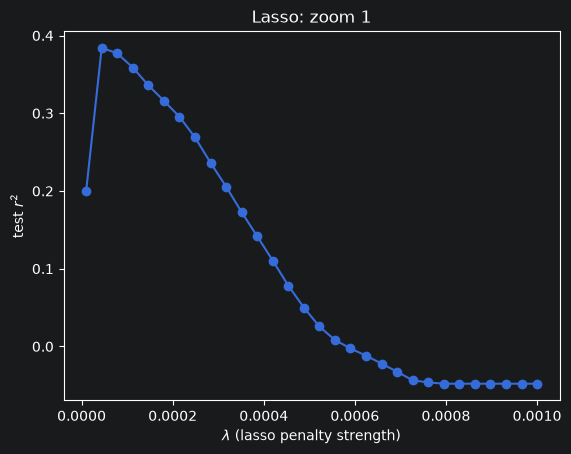

Best lambda: 4.413793103448276e-05 with test r^2 = 0.3843363110911473
Pixels kept: 194 out of 3872


In [19]:
# Zoom 1: search around the coarse peak near 10^-4
lambdas = np.linspace(0.00001, 0.001, 30)
r_sqds = []
n_nonzero = []

for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=10_000)
    lasso.fit(x_train, y_train)
    r_sqds.append(r2_score(y_test, lasso.predict(x_test)))
    n_nonzero.append(np.sum(lasso.coef_ != 0))
    print(f"lambda={lam:.2e}  test r^2={r_sqds[-1]:.3f}  pixels kept={n_nonzero[-1]}")

plt.plot(lambdas, r_sqds, "o-")
plt.xlabel("$\\lambda$ (lasso penalty strength)"); plt.ylabel("test $r^2$")
plt.title("Lasso: zoom 1")
plt.show()

best = np.argmax(r_sqds)
print("Best lambda:", lambdas[best], "with test r^2 =", r_sqds[best])
print("Pixels kept:", n_nonzero[best], "out of", x_train.shape[1])

lambda=2.00e-05  test r^2=0.320  pixels kept=300
lambda=2.50e-05  test r^2=0.342  pixels kept=264
lambda=3.00e-05  test r^2=0.356  pixels kept=249
lambda=3.50e-05  test r^2=0.368  pixels kept=220
lambda=4.00e-05  test r^2=0.378  pixels kept=202
lambda=4.50e-05  test r^2=0.385  pixels kept=188
lambda=5.00e-05  test r^2=0.389  pixels kept=168
lambda=5.50e-05  test r^2=0.389  pixels kept=148
lambda=6.00e-05  test r^2=0.389  pixels kept=135
lambda=6.50e-05  test r^2=0.384  pixels kept=120
lambda=7.00e-05  test r^2=0.381  pixels kept=105
lambda=7.50e-05  test r^2=0.378  pixels kept=96
lambda=8.00e-05  test r^2=0.376  pixels kept=96


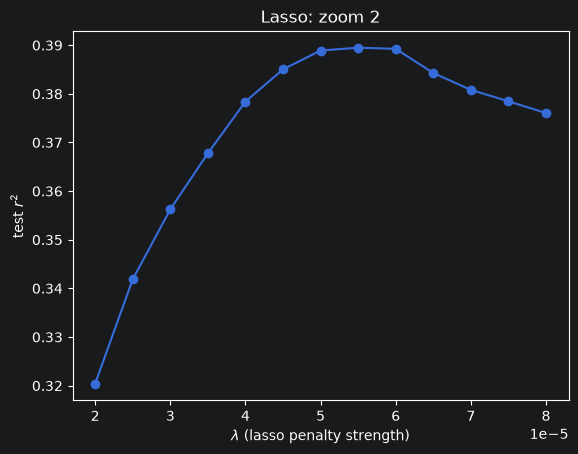

Best lambda: 5.500000000000001e-05 with test r^2 = 0.3894840070424671
Pixels kept: 148 out of 3872


In [20]:
# Zoom 2: zoom 1's points are spaced 3.4e-5 apart, too wide near its peak, so narrow the range
lambdas = np.linspace(0.00002, 0.00008, 13)
r_sqds = []
n_nonzero = []

for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=10_000)
    lasso.fit(x_train, y_train)
    r_sqds.append(r2_score(y_test, lasso.predict(x_test)))
    n_nonzero.append(np.sum(lasso.coef_ != 0))
    print(f"lambda={lam:.2e}  test r^2={r_sqds[-1]:.3f}  pixels kept={n_nonzero[-1]}")

plt.plot(lambdas, r_sqds, "o-")
plt.xlabel("$\\lambda$ (lasso penalty strength)"); plt.ylabel("test $r^2$")
plt.title("Lasso: zoom 2")
plt.show()

best = np.argmax(r_sqds)
print("Best lambda:", lambdas[best], "with test r^2 =", r_sqds[best])
print("Pixels kept:", n_nonzero[best], "out of", x_train.shape[1])

In [ ]:
"""
Answer: best lambda ≈ 5.5 * 10^-5 (test r^2 ≈ 0.389), keeping 148 of the 3872 pixels.

Notation: lambda here is the lasso penalty strength in (1/2n)*RSS + lambda*sum|B_i|. sklearn's Lasso
calls this parameter alpha. In the lab's elastic-net notation, pure lasso fixes L1_wt = 1, so the
penalty strength is the only parameter left to tune.

Method: I used the same 80/20 split as part a. I fit lasso with sklearn's Lasso, which uses the same
(1/2n) scaling as statsmodels, so these values are directly comparable. I used sklearn because
statsmodels' lasso solver was too slow with 3872 features. A coarse sweep over 10^-6 to 10^3 put
the peak near 10^-4. Finer sweeps from 10^-5 to 10^-3, then from 2*10^-5 to 8*10^-5, located the
maximum at lambda ≈ 5.5 * 10^-5.

Justification: lambda too small -> too weak a penalty, lasso keeps hundreds of pixels and overfits
the 487 training images (test r^2 drops). Lambda too large -> more coefficients are set exactly to 0,
and above about 8 * 10^-4 every pixel is dropped, so the model just predicts the mean nWBV
(test r^2 < 0). The best lambda balances the two and keeps only a small set of useful pixels.
"""